# 05. Poisson Scoreline Modelling

## 1. Notebook Objective and Statistical Framework

The previous notebooks estimated Premier League home-win, draw and away-win probabilities directly. This notebook introduces a score-based framework.

For fixture $i$, let:

$$
Y_{i,H}=\text{home-team goals},
$$

and:

$$
Y_{i,A}=\text{away-team goals}.
$$

The initial model assumes:

$$
Y_{i,H}\sim\operatorname{Poisson}(\lambda_{i,H}),
$$

and:

$$
Y_{i,A}\sim\operatorname{Poisson}(\lambda_{i,A}),
$$

where $\lambda_{i,H}$ and $\lambda_{i,A}$ are the model-implied pre-match expected goals for the home and away teams.

For a Poisson random variable with expected value $\lambda$, the probability of exactly $g$ goals is:

$$
P(Y=g)=\frac{e^{-\lambda}\lambda^g}{g!}.
$$

The modelling chain is therefore:

> pre-match features → expected goals → scoreline probabilities → H/D/A probabilities

The scoreline probabilities are aggregated into:

$$
P(H),\qquad P(D),\qquad P(A).
$$

### Research questions

This notebook investigates whether:

1. engineered pre-match variables can estimate home and away goal rates;
2. Poisson-derived probabilities outperform naive forecasts;
3. modelling goals first can compete with the direct classifiers;
4. scoreline outputs add useful interpretability;
5. the Poisson framework provides a useful component for later calibration and model blending.

### Leakage rule

`FTHG` and `FTAG` are outcomes. They are used only as targets and are explicitly excluded from the predictor matrix.

> **Run instruction:** use the project virtual environment, then select **Restart Kernel and Run All Cells**. The notebook reproduces the chronological split used in Notebooks 3 and 4.


## 2. Load, Reconstruct and Validate the Modelling Dataset

The engineered predictor dataset is loaded from `data/processed/`.

The full-time goal targets are loaded from a local raw-data cache when available. If the cache does not yet exist, the notebook reconstructs it from the same Football-Data.co.uk season files used earlier in the project.

Dates are parsed separately within each season. This avoids the mixed two-digit and four-digit year problem that affected the 2016–17 source file.

The two datasets are then joined using:

- season;
- date;
- home team;
- away team.

A successful one-to-one merge must recover exactly 3,800 fixtures without changing the engineered predictors.


In [1]:
# ============================================================
# 2. Load, Reconstruct and Validate the Modelling Dataset
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Locate the project root
# ------------------------------------------------------------

def find_project_root(start_path):
    """Return the nearest parent directory containing .git."""
    start_path = Path(start_path).resolve()

    for directory in [start_path, *start_path.parents]:
        if (directory / ".git").exists():
            return directory

    raise FileNotFoundError(
        "Could not locate the project root containing .git."
    )


project_root = find_project_root(Path.cwd())
processed_data_directory = project_root / "data" / "processed"
raw_data_directory = project_root / "data" / "raw"
raw_data_directory.mkdir(parents=True, exist_ok=True)

parquet_path = (
    processed_data_directory
    / "premier_league_model_data.parquet"
)

csv_path = (
    processed_data_directory
    / "premier_league_model_data.csv"
)


# ------------------------------------------------------------
# Robust mixed-date parser
# ------------------------------------------------------------

def parse_mixed_date_series(series):
    """
    Parse date strings that may mix two-digit and four-digit years.
    """
    text = series.astype("string").str.strip()

    try:
        parsed = pd.to_datetime(
            text,
            format="mixed",
            errors="coerce",
            dayfirst=True,
        )

    except (TypeError, ValueError):
        parsed = pd.Series(
            pd.NaT,
            index=series.index,
            dtype="datetime64[ns]",
        )

        candidate_formats = [
            "%d/%m/%Y",
            "%d/%m/%y",
            "%Y-%m-%d",
            "%d-%m-%Y",
            "%d-%m-%y",
        ]

        for date_format in candidate_formats:
            remaining_mask = parsed.isna() & text.notna()

            if not remaining_mask.any():
                break

            parsed.loc[remaining_mask] = pd.to_datetime(
                text.loc[remaining_mask],
                format=date_format,
                errors="coerce",
            )

    return parsed.dt.normalize()


# ------------------------------------------------------------
# Load the engineered modelling dataset
# ------------------------------------------------------------

if parquet_path.exists():
    model_data = pd.read_parquet(parquet_path)
    loaded_modelling_file = parquet_path
    loaded_modelling_format = "Parquet"

elif csv_path.exists():
    model_data = pd.read_csv(csv_path)
    loaded_modelling_file = csv_path
    loaded_modelling_format = "CSV"

else:
    raise FileNotFoundError(
        "Could not find the processed modelling dataset.\n\n"
        f"Checked:\n- {parquet_path}\n- {csv_path}"
    )


def find_first_existing_column(
    dataframe,
    candidates,
    label,
    required=True,
):
    """Return the first candidate column present in a DataFrame."""
    for candidate in candidates:
        if candidate in dataframe.columns:
            return candidate

    if required:
        raise KeyError(
            f"Could not identify the {label} column. "
            f"Checked: {candidates}"
        )

    return None


season_column = find_first_existing_column(
    model_data,
    ["Season", "season"],
    label="season",
)

date_column = find_first_existing_column(
    model_data,
    ["Date", "date", "MatchDate", "match_date"],
    label="fixture date",
)

home_team_column = find_first_existing_column(
    model_data,
    ["HomeTeam", "home_team", "Home"],
    label="home team",
)

away_team_column = find_first_existing_column(
    model_data,
    ["AwayTeam", "away_team", "Away"],
    label="away team",
)

target_column = find_first_existing_column(
    model_data,
    ["FTR", "Result", "result", "FullTimeResult"],
    label="full-time result",
)

model_data[date_column] = parse_mixed_date_series(
    model_data[date_column]
)

model_data[target_column] = (
    model_data[target_column]
    .astype("string")
    .str.strip()
    .str.upper()
)


# ------------------------------------------------------------
# Load or reconstruct the historical goal targets
# ------------------------------------------------------------

goal_target_path = (
    raw_data_directory
    / "premier_league_goal_targets_2015_16_to_2024_25.csv"
)

season_codes = {
    "2015-16": "1516",
    "2016-17": "1617",
    "2017-18": "1718",
    "2018-19": "1819",
    "2019-20": "1920",
    "2020-21": "2021",
    "2021-22": "2122",
    "2022-23": "2223",
    "2023-24": "2324",
    "2024-25": "2425",
}

football_data_url_template = (
    "https://www.football-data.co.uk/"
    "mmz4281/{season_code}/E0.csv"
)

required_source_columns = [
    "Date",
    "HomeTeam",
    "AwayTeam",
    "FTHG",
    "FTAG",
    "FTR",
]


def validate_goal_target_frame(dataframe):
    """Return True only when a cached goal-target file is usable."""
    required_columns = {
        "Season",
        "Date",
        "HomeTeam",
        "AwayTeam",
        "FTHG",
        "FTAG",
        "FTR",
    }

    if not required_columns.issubset(dataframe.columns):
        return False

    if len(dataframe) != 3800:
        return False

    parsed_dates = parse_mixed_date_series(dataframe["Date"])

    return bool(
        parsed_dates.notna().all()
        and dataframe[[
            "Season",
            "HomeTeam",
            "AwayTeam",
            "FTHG",
            "FTAG",
            "FTR",
        ]].notna().all().all()
    )


use_cached_goal_targets = False

if goal_target_path.exists():
    cached_goal_targets = pd.read_csv(goal_target_path)
    use_cached_goal_targets = validate_goal_target_frame(
        cached_goal_targets
    )

if use_cached_goal_targets:
    goal_targets = cached_goal_targets.copy()
    goal_target_source = "Local raw-data cache"

else:
    goal_target_frames = []

    for season, season_code in season_codes.items():
        season_url = football_data_url_template.format(
            season_code=season_code
        )

        season_data = pd.read_csv(season_url)

        missing_columns = sorted(
            set(required_source_columns)
            - set(season_data.columns)
        )

        assert not missing_columns, (
            f"{season} is missing required columns: "
            f"{missing_columns}"
        )

        season_goal_targets = (
            season_data.loc[
                season_data["HomeTeam"].notna()
                & season_data["AwayTeam"].notna(),
                required_source_columns,
            ]
            .copy()
        )

        season_goal_targets.insert(0, "Season", season)

        # Parse each season independently so the 2016–17
        # two-digit-year format cannot be coerced to NaT.
        season_goal_targets["Date"] = parse_mixed_date_series(
            season_goal_targets["Date"]
        )

        assert len(season_goal_targets) == 380, (
            f"Expected 380 fixtures in {season}, but found "
            f"{len(season_goal_targets)}."
        )

        goal_target_frames.append(season_goal_targets)

    goal_targets = pd.concat(
        goal_target_frames,
        ignore_index=True,
    )

    goal_targets.to_csv(
        goal_target_path,
        index=False,
    )

    goal_target_source = "Football-Data.co.uk reconstruction"


# ------------------------------------------------------------
# Standardise and validate goal-target values
# ------------------------------------------------------------

goal_targets["Date"] = parse_mixed_date_series(
    goal_targets["Date"]
)

goal_targets["Season"] = (
    goal_targets["Season"]
    .astype("string")
    .str.strip()
)

goal_targets["HomeTeam"] = (
    goal_targets["HomeTeam"]
    .astype("string")
    .str.strip()
)

goal_targets["AwayTeam"] = (
    goal_targets["AwayTeam"]
    .astype("string")
    .str.strip()
)

goal_targets["FTR"] = (
    goal_targets["FTR"]
    .astype("string")
    .str.strip()
    .str.upper()
)

for goal_column in ["FTHG", "FTAG"]:
    goal_targets[goal_column] = pd.to_numeric(
        goal_targets[goal_column],
        errors="coerce",
    )

assert len(model_data) == 3800, (
    f"Expected 3,800 engineered fixtures, found {len(model_data)}."
)

assert len(goal_targets) == 3800, (
    f"Expected 3,800 goal-target fixtures, found {len(goal_targets)}."
)

assert goal_targets[[
    "Season",
    "Date",
    "HomeTeam",
    "AwayTeam",
    "FTHG",
    "FTAG",
    "FTR",
]].notna().all().all(), (
    "The goal-target dataset contains missing required values."
)

assert (goal_targets[["FTHG", "FTAG"]] >= 0).all().all(), (
    "Goal targets cannot be negative."
)

assert np.allclose(
    goal_targets[["FTHG", "FTAG"]],
    goal_targets[["FTHG", "FTAG"]].round(),
), "Goal targets must be whole numbers."

goal_targets["FTHG"] = goal_targets["FTHG"].astype(int)
goal_targets["FTAG"] = goal_targets["FTAG"].astype(int)

source_fixture_keys = [
    "Season",
    "Date",
    "HomeTeam",
    "AwayTeam",
]

assert not goal_targets.duplicated(
    subset=source_fixture_keys
).any(), "Duplicate goal-target fixtures were detected."

reconstructed_results = np.select(
    [
        goal_targets["FTHG"] > goal_targets["FTAG"],
        goal_targets["FTHG"] == goal_targets["FTAG"],
        goal_targets["FTHG"] < goal_targets["FTAG"],
    ],
    ["H", "D", "A"],
    default=None,
)

assert np.array_equal(
    reconstructed_results,
    goal_targets["FTR"].to_numpy(),
), "At least one recorded result does not match its scoreline."


# ------------------------------------------------------------
# Rename source columns and merge onto engineered predictors
# ------------------------------------------------------------

goal_targets_for_merge = goal_targets.rename(
    columns={
        "Season": season_column,
        "Date": date_column,
        "HomeTeam": home_team_column,
        "AwayTeam": away_team_column,
        "FTHG": "HomeGoalsTarget",
        "FTAG": "AwayGoalsTarget",
        "FTR": "GoalSourceResult",
    }
)

identifier_columns = [
    season_column,
    date_column,
    home_team_column,
    away_team_column,
]

poisson_data = model_data.merge(
    goal_targets_for_merge[
        identifier_columns
        + [
            "HomeGoalsTarget",
            "AwayGoalsTarget",
            "GoalSourceResult",
        ]
    ],
    on=identifier_columns,
    how="left",
    validate="one_to_one",
    indicator=True,
)

assert len(poisson_data) == len(model_data), (
    "The goal-target merge changed the number of fixtures."
)

assert (poisson_data["_merge"] == "both").all(), (
    "At least one engineered fixture did not match a goal target."
)

assert poisson_data[[
    "HomeGoalsTarget",
    "AwayGoalsTarget",
    "GoalSourceResult",
]].notna().all().all(), (
    "The merged modelling dataset contains missing targets."
)

assert (
    poisson_data[target_column]
    == poisson_data["GoalSourceResult"]
).all(), (
    "The engineered result target does not match the goal source."
)

poisson_data = poisson_data.drop(columns="_merge")


# ------------------------------------------------------------
# Compact validation output
# ------------------------------------------------------------

season_goal_summary = (
    poisson_data
    .groupby(season_column, sort=False)
    .agg(
        Fixtures=(season_column, "size"),
        MeanHomeGoals=("HomeGoalsTarget", "mean"),
        MeanAwayGoals=("AwayGoalsTarget", "mean"),
        FirstDate=(date_column, "min"),
        LastDate=(date_column, "max"),
    )
    .reset_index()
)

assert (season_goal_summary["Fixtures"] == 380).all(), (
    "Every season should contain 380 fixtures."
)

print("Poisson modelling dataset assembled successfully.")
print(f"Processed data format: {loaded_modelling_format}")
print(f"Processed data file: {loaded_modelling_file}")
print(f"Goal-target source: {goal_target_source}")
print(f"Fixtures: {len(poisson_data):,}")
print(f"Columns: {len(poisson_data.columns):,}")

display(season_goal_summary.round(3))
display(
    poisson_data[
        identifier_columns
        + [
            "HomeGoalsTarget",
            "AwayGoalsTarget",
            target_column,
        ]
    ].head(10)
)


Poisson modelling dataset assembled successfully.
Processed data format: Parquet
Processed data file: C:\Users\kiera\OneDrive\Desktop\premier-league-probability-engine\data\processed\premier_league_model_data.parquet
Goal-target source: Local raw-data cache
Fixtures: 3,800
Columns: 78


C:\Users\kiera\AppData\Local\Temp\ipykernel_6696\2082721696.py:505: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(season_goal_summary.round(3))


,Season,Fixtures,MeanHomeGoals,MeanAwayGoals,FirstDate,LastDate
0,2015-16,380,1.492,1.208,2015-01-11,2016-12-03
1,2016-17,380,1.597,1.203,2016-01-10,2017-12-05
2,2017-18,380,1.532,1.147,2017-01-10,2018-12-03
3,2018-19,380,1.568,1.253,2018-01-09,2019-12-05
4,2019-20,380,1.516,1.205,2019-01-09,2020-12-07
5,2020-21,380,1.353,1.342,2020-01-11,2021-12-05
6,2021-22,380,1.513,1.305,2021-01-11,2022-12-05
7,2022-23,380,1.634,1.218,2022-01-09,2023-12-03
8,2023-24,380,1.800,1.479,2023-01-09,2024-12-05
9,2024-25,380,1.513,1.421,2024-01-09,2025-12-04


,Season,Date,HomeTeam,AwayTeam,HomeGoalsTarget,AwayGoalsTarget,FTR
0,2015-16,2015-08-08,Bournemouth,Aston Villa,0,1,A
1,2015-16,2015-08-08,Chelsea,Swansea,2,2,D
2,2015-16,2015-08-08,Everton,Watford,2,2,D
3,2015-16,2015-08-08,Leicester,Sunderland,4,2,H
4,2015-16,2015-08-08,Man United,Tottenham,1,0,H
5,2015-16,2015-08-08,Norwich,Crystal Palace,1,3,A
6,2015-16,2015-09-08,Arsenal,West Ham,0,2,A
7,2015-16,2015-09-08,Newcastle,Southampton,2,2,D
8,2015-16,2015-09-08,Stoke,Liverpool,0,1,A
9,2015-16,2015-10-08,West Brom,Man City,0,3,A


### Results and interpretation

The completed table must contain 3,800 one-to-one matched fixtures. The goal source is used only to supply the observed score targets and independently verify the recorded H/D/A result.

The date repair is intentionally narrow: each season is parsed independently, which prevents the 2016–17 two-digit year strings from being interpreted using a four-digit-year format inferred from another season.


## 3. Predictor Definition and Chronological Split

The predictor matrix is constructed from the numeric pre-match variables already approved in the feature-engineering notebook.

The following are excluded:

- fixture identifiers;
- the H/D/A target;
- home and away goal targets;
- the independently loaded result check;
- any recognised raw match-statistic columns.

The same chronological structure used previously is retained:

- earliest eight seasons: training;
- 2023–24: validation;
- 2024–25: locked test.

No random shuffling is permitted.


In [2]:
# ============================================================
# 3. Predictor Definition and Chronological Split
# ============================================================

class_order = ["H", "D", "A"]

goal_target_columns = [
    "HomeGoalsTarget",
    "AwayGoalsTarget",
    "GoalSourceResult",
]

excluded_columns = set(
    identifier_columns
    + [target_column]
    + goal_target_columns
)

feature_columns = [
    column
    for column in poisson_data.columns
    if (
        column not in excluded_columns
        and pd.api.types.is_numeric_dtype(poisson_data[column])
    )
]

blocked_exact_names = {
    "FTHG",
    "FTAG",
    "FTR",
    "HTHG",
    "HTAG",
    "HTR",
    "HS",
    "AS",
    "HST",
    "AST",
    "HF",
    "AF",
    "HC",
    "AC",
    "HY",
    "AY",
    "HR",
    "AR",
    "HomeGoalsTarget",
    "AwayGoalsTarget",
}

blocked_predictors = sorted(
    set(feature_columns).intersection(blocked_exact_names)
)

assert feature_columns, "No numeric predictors were identified."
assert not blocked_predictors, (
    "Post-match variables entered the predictor matrix: "
    f"{blocked_predictors}"
)
assert target_column not in feature_columns
assert not set(identifier_columns).intersection(feature_columns)


# ------------------------------------------------------------
# Construct full predictor and target objects
# ------------------------------------------------------------

X = poisson_data[feature_columns].copy()
y_outcome = poisson_data[target_column].copy()
y_home_goals = poisson_data["HomeGoalsTarget"].astype(int).copy()
y_away_goals = poisson_data["AwayGoalsTarget"].astype(int).copy()
metadata = poisson_data[identifier_columns].copy()

ordered_seasons = (
    poisson_data
    .groupby(season_column)[date_column]
    .min()
    .sort_values()
    .index
    .tolist()
)

assert len(ordered_seasons) >= 3, (
    "At least three seasons are required for the split."
)

training_seasons = ordered_seasons[:-2]
validation_season = ordered_seasons[-2]
test_season = ordered_seasons[-1]

train_mask = poisson_data[season_column].isin(training_seasons)
validation_mask = poisson_data[season_column].eq(validation_season)
test_mask = poisson_data[season_column].eq(test_season)

assert (train_mask | validation_mask | test_mask).all()
assert not (train_mask & validation_mask).any()
assert not (train_mask & test_mask).any()
assert not (validation_mask & test_mask).any()

X_train = X.loc[train_mask].copy()
X_validation = X.loc[validation_mask].copy()
X_test = X.loc[test_mask].copy()

y_train_outcome = y_outcome.loc[train_mask].copy()
y_validation_outcome = y_outcome.loc[validation_mask].copy()
y_test_outcome = y_outcome.loc[test_mask].copy()

y_train_home_goals = y_home_goals.loc[train_mask].copy()
y_validation_home_goals = y_home_goals.loc[validation_mask].copy()
y_test_home_goals = y_home_goals.loc[test_mask].copy()

y_train_away_goals = y_away_goals.loc[train_mask].copy()
y_validation_away_goals = y_away_goals.loc[validation_mask].copy()
y_test_away_goals = y_away_goals.loc[test_mask].copy()

metadata_train = metadata.loc[train_mask].copy()
metadata_validation = metadata.loc[validation_mask].copy()
metadata_test = metadata.loc[test_mask].copy()

for split_name, split_X, split_outcome, split_home, split_away in [
    (
        "Train",
        X_train,
        y_train_outcome,
        y_train_home_goals,
        y_train_away_goals,
    ),
    (
        "Validation",
        X_validation,
        y_validation_outcome,
        y_validation_home_goals,
        y_validation_away_goals,
    ),
    (
        "Test",
        X_test,
        y_test_outcome,
        y_test_home_goals,
        y_test_away_goals,
    ),
]:
    assert split_X.index.equals(split_outcome.index)
    assert split_X.index.equals(split_home.index)
    assert split_X.index.equals(split_away.index)
    assert (split_home >= 0).all()
    assert (split_away >= 0).all()

split_summary = pd.DataFrame(
    {
        "Split": ["Train", "Validation", "Test"],
        "Seasons": [
            ", ".join(training_seasons),
            validation_season,
            test_season,
        ],
        "Fixtures": [
            len(X_train),
            len(X_validation),
            len(X_test),
        ],
        "Features": [
            X_train.shape[1],
            X_validation.shape[1],
            X_test.shape[1],
        ],
        "MeanHomeGoals": [
            y_train_home_goals.mean(),
            y_validation_home_goals.mean(),
            y_test_home_goals.mean(),
        ],
        "MeanAwayGoals": [
            y_train_away_goals.mean(),
            y_validation_away_goals.mean(),
            y_test_away_goals.mean(),
        ],
    }
)

print("Predictors and chronological splits created successfully.")
print(f"Predictors retained: {len(feature_columns)}")
print(f"Validation season: {validation_season}")
print(f"Locked test season: {test_season}")

display(split_summary.round(4))
display(pd.Series(feature_columns, name="Predictor").to_frame())


Predictors and chronological splits created successfully.
Predictors retained: 70
Validation season: 2023-24
Locked test season: 2024-25


,Split,Seasons,Fixtures,Features,MeanHomeGoals,MeanAwayGoals
0,Train,"2015-16, 2016-17, 2017-18, 2018-19, 2019-20, 2...",3040,70,1.5257,1.2352
1,Validation,2023-24,380,70,1.8000,1.4789
2,Test,2024-25,380,70,1.5132,1.4211


,Predictor
0,HomeEloBefore
1,AwayEloBefore
2,HomeRollingPoints5
3,AwayRollingPoints5
4,HomeRollingGoalsFor5
...,...
65,HomeBottom3Before
66,AwayTop4Before
67,AwayTop6Before
68,AwayTopHalfBefore


### Results and interpretation

The split is deliberately time ordered. Every validation and test prediction is therefore generated for a fixture that occurs after all training observations.

The goal targets are aligned to the same fixture indices as the H/D/A target, which allows both goal-level and outcome-level evaluation without changing the underlying sample.


## 4. Goal Distribution and the Poisson Assumption

A Poisson variable has equal conditional mean and variance. Football goals do not need to follow a perfect unconditional Poisson distribution for Poisson regression to be useful, but large differences between the observed mean and variance can indicate overdispersion or omitted structure.

This section examines:

- home- and away-goal frequencies;
- mean and variance by split;
- seasonal scoring levels;
- the frequency of high-scoring tail outcomes.


Goal-distribution analysis completed successfully.


,Split,Side,Fixtures,MeanGoals,VarianceGoals,VarianceToMean,ZeroGoalRate,FourPlusGoalRate
0,Train,Home,3040,1.5257,1.7387,1.1397,0.2378,0.0812
1,Train,Away,3040,1.2352,1.4514,1.1750,0.3253,0.0493
2,Validation,Home,380,1.8000,1.8649,1.0361,0.1789,0.1132
3,Validation,Away,380,1.4789,1.6328,1.1040,0.2342,0.0737
4,Test,Home,380,1.5132,1.6331,1.0792,0.2395,0.0868
5,Test,Away,380,1.4211,1.4159,0.9964,0.2289,0.0553


,Season,Fixtures,MeanHomeGoals,MeanAwayGoals,MeanTotalGoals
0,2015-16,380,1.4921,1.2079,2.7000
1,2016-17,380,1.5974,1.2026,2.8000
2,2017-18,380,1.5316,1.1474,2.6789
3,2018-19,380,1.5684,1.2526,2.8211
4,2019-20,380,1.5158,1.2053,2.7211
5,2020-21,380,1.3526,1.3421,2.6947
6,2021-22,380,1.5132,1.3053,2.8184
7,2022-23,380,1.6342,1.2184,2.8526
8,2023-24,380,1.8000,1.4789,3.2789
9,2024-25,380,1.5132,1.4211,2.9342


,Side,Goals,Fixtures,Percentage
0,Home,0,882,23.211
1,Home,1,1214,31.947
2,Home,2,904,23.789
3,Home,3,477,12.553
4,Home,4,214,5.632
5,Home,5,80,2.105
6,Home,6,20,0.526
7,Home,7,6,0.158
8,Home,8,1,0.026
9,Home,9,2,0.053


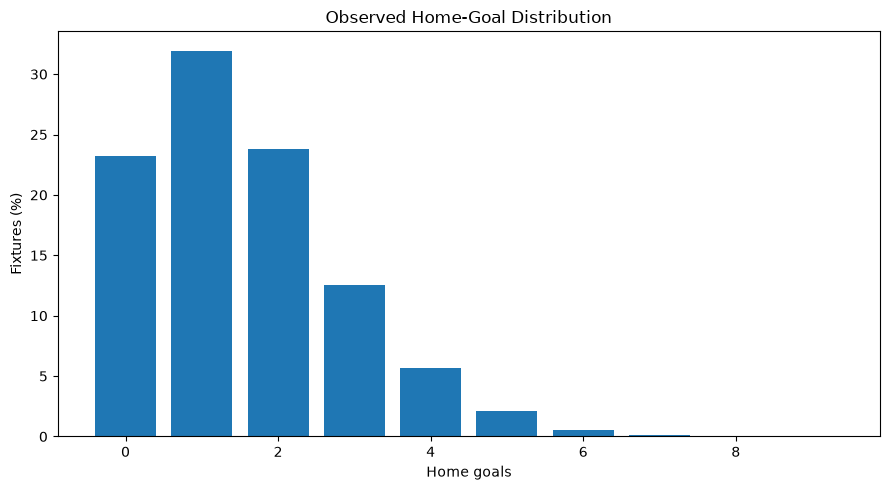

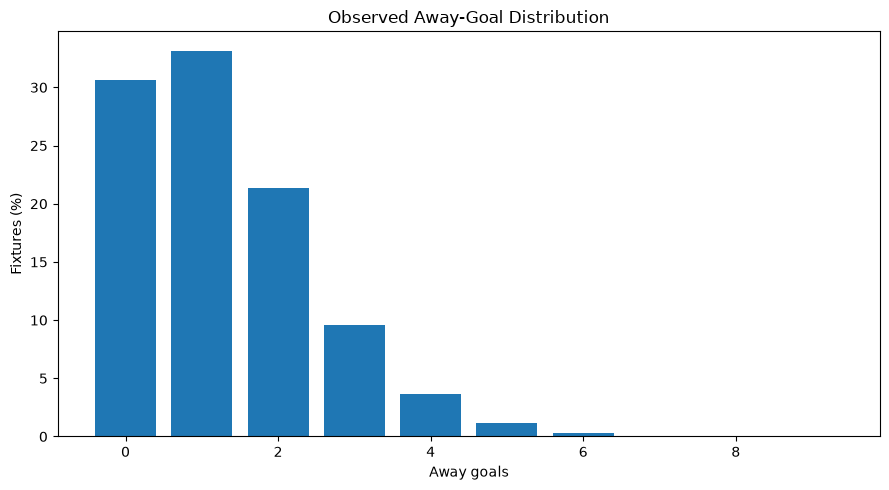

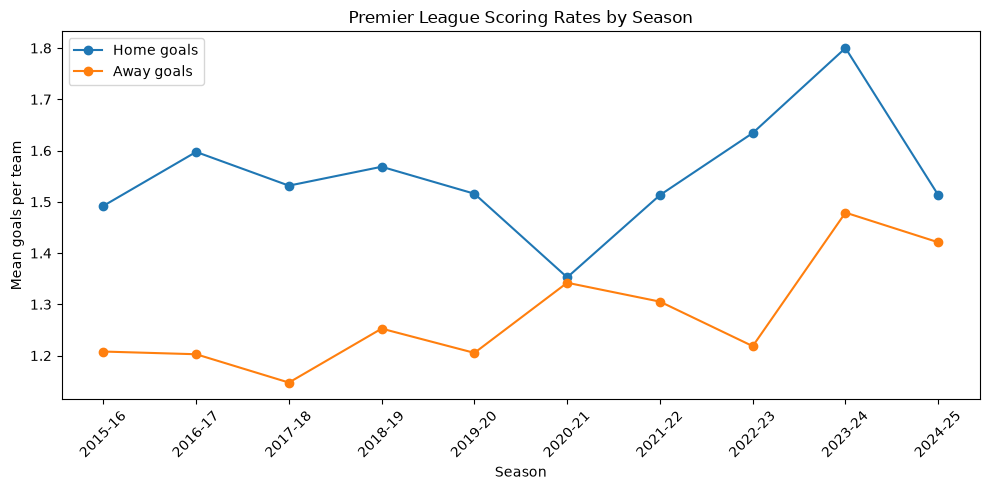

In [3]:
# ============================================================
# 4. Goal Distribution and the Poisson Assumption
# ============================================================

import matplotlib.pyplot as plt


def create_goal_distribution(goals, side):
    """Return a complete integer goal-frequency table."""
    maximum_goals = int(goals.max())

    distribution = (
        goals
        .value_counts()
        .reindex(range(maximum_goals + 1), fill_value=0)
        .rename_axis("Goals")
        .reset_index(name="Fixtures")
    )

    distribution["Percentage"] = (
        100 * distribution["Fixtures"] / len(goals)
    )

    distribution.insert(0, "Side", side)
    return distribution


home_goal_distribution = create_goal_distribution(
    y_home_goals,
    "Home",
)

away_goal_distribution = create_goal_distribution(
    y_away_goals,
    "Away",
)

goal_distribution = pd.concat(
    [home_goal_distribution, away_goal_distribution],
    ignore_index=True,
)

goal_dispersion_records = []

for split_name, home_goals, away_goals in [
    ("Train", y_train_home_goals, y_train_away_goals),
    (
        "Validation",
        y_validation_home_goals,
        y_validation_away_goals,
    ),
    ("Test", y_test_home_goals, y_test_away_goals),
]:
    for side, goals in [
        ("Home", home_goals),
        ("Away", away_goals),
    ]:
        mean_goals = float(goals.mean())
        variance_goals = float(goals.var(ddof=1))

        goal_dispersion_records.append(
            {
                "Split": split_name,
                "Side": side,
                "Fixtures": len(goals),
                "MeanGoals": mean_goals,
                "VarianceGoals": variance_goals,
                "VarianceToMean": (
                    variance_goals / mean_goals
                    if mean_goals > 0
                    else np.nan
                ),
                "ZeroGoalRate": float((goals == 0).mean()),
                "FourPlusGoalRate": float((goals >= 4).mean()),
            }
        )


goal_dispersion_summary = pd.DataFrame(
    goal_dispersion_records
)

season_scoring_summary = (
    poisson_data
    .groupby(season_column, sort=False)
    .agg(
        Fixtures=(season_column, "size"),
        MeanHomeGoals=("HomeGoalsTarget", "mean"),
        MeanAwayGoals=("AwayGoalsTarget", "mean"),
        MeanTotalGoals=(
            "HomeGoalsTarget",
            lambda values: np.nan,
        ),
    )
    .reset_index()
)

season_total_goals = (
    poisson_data["HomeGoalsTarget"]
    + poisson_data["AwayGoalsTarget"]
)

season_scoring_summary["MeanTotalGoals"] = (
    season_total_goals
    .groupby(poisson_data[season_column])
    .mean()
    .reindex(season_scoring_summary[season_column])
    .to_numpy()
)

print("Goal-distribution analysis completed successfully.")

display(goal_dispersion_summary.round(4))
display(season_scoring_summary.round(4))
display(goal_distribution.round(3))

plt.figure(figsize=(9, 5))
plt.bar(
    home_goal_distribution["Goals"],
    home_goal_distribution["Percentage"],
)
plt.xlabel("Home goals")
plt.ylabel("Fixtures (%)")
plt.title("Observed Home-Goal Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(
    away_goal_distribution["Goals"],
    away_goal_distribution["Percentage"],
)
plt.xlabel("Away goals")
plt.ylabel("Fixtures (%)")
plt.title("Observed Away-Goal Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(
    season_scoring_summary[season_column],
    season_scoring_summary["MeanHomeGoals"],
    marker="o",
    label="Home goals",
)
plt.plot(
    season_scoring_summary[season_column],
    season_scoring_summary["MeanAwayGoals"],
    marker="o",
    label="Away goals",
)
plt.xticks(rotation=45)
plt.xlabel("Season")
plt.ylabel("Mean goals per team")
plt.title("Premier League Scoring Rates by Season")
plt.legend()
plt.tight_layout()
plt.show()


### Results and interpretation

The observed goal distributions are positively skewed. Most teams score between zero and two goals, while high-scoring outcomes become progressively less common. Across all 3,800 fixtures, home teams scored zero goals in 23.21% of matches and away teams scored zero in 30.66%, consistent with an overall home-scoring advantage.

The variance-to-mean ratios are close to, but usually slightly above, one. They range from 1.0361 to 1.1750 for the training and validation samples, indicating mild overdispersion rather than a severe violation of the Poisson assumption. Away goals in the test season are almost exactly equidispersed, with a ratio of 0.9964.

Scoring conditions also vary through time. The 2020–21 season is notable because mean home and away goals were almost identical at 1.3526 and 1.3421, respectively, consistent with a temporary reduction in home advantage. By contrast, 2023–24 was the highest-scoring season in the sample, averaging 3.2789 total goals per match.

These diagnostics support Poisson regression as a sensible starting point, while the remaining overdispersion motivates later comparison with extensions such as negative-binomial or Dixon–Coles models.

## 5. Preprocessing and Probability Helpers

Median imputation and standardisation are fitted using the training seasons only.

Standardisation is used because Poisson regression applies regularisation to its coefficients. Without scaling, variables measured on larger numerical scales would be penalised differently from variables measured on smaller scales.

The helper functions below:

- convert expected goals into scoreline matrices;
- aggregate scorelines into H/D/A probabilities;
- preserve the project probability order `(H, D, A)`;
- calculate class-order-safe multiclass log loss;
- calculate multiclass Brier score;
- evaluate expected-goal predictions.


In [4]:
# ============================================================
# 5. Preprocessing and Probability Helpers
# ============================================================

from scipy.stats import poisson

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    mean_poisson_deviance,
)
from sklearn.preprocessing import StandardScaler


# ------------------------------------------------------------
# Fit preprocessing using training data only
# ------------------------------------------------------------

poisson_imputer = SimpleImputer(
    strategy="median",
    keep_empty_features=True,
)

poisson_scaler = StandardScaler()

X_train_imputed_array = poisson_imputer.fit_transform(X_train)
X_validation_imputed_array = poisson_imputer.transform(X_validation)
X_test_imputed_array = poisson_imputer.transform(X_test)

X_train_scaled_array = poisson_scaler.fit_transform(
    X_train_imputed_array
)

X_validation_scaled_array = poisson_scaler.transform(
    X_validation_imputed_array
)

X_test_scaled_array = poisson_scaler.transform(
    X_test_imputed_array
)

X_train_processed = pd.DataFrame(
    X_train_scaled_array,
    index=X_train.index,
    columns=feature_columns,
)

X_validation_processed = pd.DataFrame(
    X_validation_scaled_array,
    index=X_validation.index,
    columns=feature_columns,
)

X_test_processed = pd.DataFrame(
    X_test_scaled_array,
    index=X_test.index,
    columns=feature_columns,
)

for split_name, processed_X, original_X in [
    ("Train", X_train_processed, X_train),
    ("Validation", X_validation_processed, X_validation),
    ("Test", X_test_processed, X_test),
]:
    assert processed_X.shape == original_X.shape
    assert processed_X.index.equals(original_X.index)
    assert list(processed_X.columns) == feature_columns
    assert np.isfinite(processed_X.to_numpy()).all(), (
        f"{split_name} predictors contain non-finite values."
    )


# ------------------------------------------------------------
# Probability and evaluation helpers
# ------------------------------------------------------------

MAX_MODELLED_GOALS = 10
MINIMUM_EXPECTED_GOALS = 1e-6


def poisson_goal_probabilities(
    expected_goals,
    max_goals=MAX_MODELLED_GOALS,
    fold_tail=True,
):
    """
    Return probabilities for 0, ..., max_goals.

    When fold_tail=True, the final bucket includes max_goals or more,
    ensuring that the returned probabilities sum to one.
    """
    expected_goals = max(
        float(expected_goals),
        MINIMUM_EXPECTED_GOALS,
    )

    goal_counts = np.arange(max_goals + 1)
    probabilities = poisson.pmf(goal_counts, expected_goals)

    if fold_tail:
        residual_probability = max(
            0.0,
            1.0 - probabilities.sum(),
        )
        probabilities[-1] += residual_probability

    probabilities = probabilities / probabilities.sum()
    return probabilities


def create_scoreline_probability_matrix(
    home_expected_goals,
    away_expected_goals,
    max_goals=MAX_MODELLED_GOALS,
    fold_tail=True,
):
    """Return a home-goals by away-goals scoreline matrix."""
    home_probabilities = poisson_goal_probabilities(
        home_expected_goals,
        max_goals=max_goals,
        fold_tail=fold_tail,
    )

    away_probabilities = poisson_goal_probabilities(
        away_expected_goals,
        max_goals=max_goals,
        fold_tail=fold_tail,
    )

    matrix = np.outer(
        home_probabilities,
        away_probabilities,
    )

    return matrix / matrix.sum()


def expected_goals_to_outcome_probabilities(
    home_expected_goals,
    away_expected_goals,
    index,
    max_goals=MAX_MODELLED_GOALS,
):
    """Convert aligned expected-goal forecasts into H/D/A probabilities."""
    home_expected_goals = np.asarray(
        home_expected_goals,
        dtype=float,
    )

    away_expected_goals = np.asarray(
        away_expected_goals,
        dtype=float,
    )

    assert len(home_expected_goals) == len(index)
    assert len(away_expected_goals) == len(index)
    assert np.isfinite(home_expected_goals).all()
    assert np.isfinite(away_expected_goals).all()
    assert (home_expected_goals > 0).all()
    assert (away_expected_goals > 0).all()

    probability_records = []

    for home_rate, away_rate in zip(
        home_expected_goals,
        away_expected_goals,
    ):
        scoreline_matrix = create_scoreline_probability_matrix(
            home_rate,
            away_rate,
            max_goals=max_goals,
            fold_tail=True,
        )

        home_win_probability = float(
            np.tril(scoreline_matrix, k=-1).sum()
        )

        draw_probability = float(
            np.trace(scoreline_matrix)
        )

        away_win_probability = float(
            np.triu(scoreline_matrix, k=1).sum()
        )

        probability_records.append(
            {
                "H": home_win_probability,
                "D": draw_probability,
                "A": away_win_probability,
            }
        )

    probability_frame = pd.DataFrame(
        probability_records,
        index=index,
        columns=class_order,
    )

    validate_probability_frame(
        probability_frame,
        expected_index=index,
        name="Poisson outcome forecast",
    )

    return probability_frame


def validate_probability_frame(
    probability_frame,
    expected_index,
    name,
):
    """Validate alignment, class order and probability sums."""
    assert isinstance(probability_frame, pd.DataFrame)
    assert probability_frame.index.equals(expected_index), (
        f"{name}: fixture index is misaligned."
    )
    assert list(probability_frame.columns) == class_order, (
        f"{name}: columns must be ordered as {class_order}."
    )
    assert np.isfinite(probability_frame.to_numpy()).all(), (
        f"{name}: non-finite probabilities detected."
    )
    assert (probability_frame.to_numpy() >= 0).all(), (
        f"{name}: negative probabilities detected."
    )
    assert (probability_frame.to_numpy() <= 1).all(), (
        f"{name}: probabilities above one detected."
    )
    assert np.allclose(
        probability_frame.sum(axis=1),
        1.0,
        atol=1e-10,
    ), f"{name}: probabilities do not sum to one."


def multiclass_log_loss(
    y_true,
    probability_frame,
    labels=class_order,
):
    """Calculate multiclass log loss without sklearn class reordering."""
    validate_probability_frame(
        probability_frame,
        expected_index=y_true.index,
        name="Log-loss probability frame",
    )

    label_to_position = {
        label: position
        for position, label in enumerate(labels)
    }

    observed_positions = np.array(
        [label_to_position[value] for value in y_true],
        dtype=int,
    )

    probability_array = probability_frame[labels].to_numpy()

    observed_probabilities = probability_array[
        np.arange(len(y_true)),
        observed_positions,
    ]

    observed_probabilities = np.clip(
        observed_probabilities,
        1e-15,
        1.0,
    )

    return float(-np.mean(np.log(observed_probabilities)))


def multiclass_brier_score(
    y_true,
    probability_frame,
    labels=class_order,
):
    """Return the mean summed squared probability error."""
    validate_probability_frame(
        probability_frame,
        expected_index=y_true.index,
        name="Brier-score probability frame",
    )

    observed_matrix = np.column_stack(
        [
            (y_true.to_numpy() == label).astype(float)
            for label in labels
        ]
    )

    probability_array = probability_frame[labels].to_numpy()

    return float(
        np.mean(
            np.sum(
                (probability_array - observed_matrix) ** 2,
                axis=1,
            )
        )
    )


def evaluate_outcome_probabilities(
    model_name,
    split_name,
    y_true,
    probability_frame,
):
    """Return H/D/A probability metrics for one model and split."""
    predicted_outcomes = probability_frame.idxmax(axis=1)

    return {
        "Model": model_name,
        "Split": split_name,
        "Fixtures": len(y_true),
        "LogLoss": multiclass_log_loss(
            y_true,
            probability_frame,
        ),
        "BrierScore": multiclass_brier_score(
            y_true,
            probability_frame,
        ),
        "Accuracy": accuracy_score(
            y_true,
            predicted_outcomes,
        ),
    }


def evaluate_goal_predictions(
    model_name,
    split_name,
    side,
    actual_goals,
    expected_goals,
):
    """Return count-forecast metrics for one side and split."""
    expected_goals = np.clip(
        np.asarray(expected_goals, dtype=float),
        MINIMUM_EXPECTED_GOALS,
        None,
    )

    return {
        "Model": model_name,
        "Split": split_name,
        "Side": side,
        "Fixtures": len(actual_goals),
        "ActualMean": float(actual_goals.mean()),
        "PredictedMean": float(expected_goals.mean()),
        "MeanAbsoluteError": mean_absolute_error(
            actual_goals,
            expected_goals,
        ),
        "MeanPoissonDeviance": mean_poisson_deviance(
            actual_goals,
            expected_goals,
        ),
    }


preprocessing_summary = pd.DataFrame(
    {
        "Split": ["Train", "Validation", "Test"],
        "Fixtures": [
            len(X_train_processed),
            len(X_validation_processed),
            len(X_test_processed),
        ],
        "Features": [
            X_train_processed.shape[1],
            X_validation_processed.shape[1],
            X_test_processed.shape[1],
        ],
        "MissingBefore": [
            int(X_train.isna().sum().sum()),
            int(X_validation.isna().sum().sum()),
            int(X_test.isna().sum().sum()),
        ],
        "MissingAfter": [
            int(X_train_processed.isna().sum().sum()),
            int(X_validation_processed.isna().sum().sum()),
            int(X_test_processed.isna().sum().sum()),
        ],
    }
)

print("Poisson preprocessing and helper functions are ready.")
print(f"Maximum modelled goal bucket: {MAX_MODELLED_GOALS}+")

display(preprocessing_summary)


Poisson preprocessing and helper functions are ready.
Maximum modelled goal bucket: 10+


,Split,Fixtures,Features,MissingBefore,MissingAfter
0,Train,3040,70,18791,0
1,Validation,380,70,2351,0
2,Test,380,70,2321,0


### Results and interpretation

All preprocessing parameters are learned from the training period. The validation and test fixtures are transformed using those fixed training estimates.

The final goal bucket represents ten or more goals. Folding the extremely small residual tail into that bucket preserves a total probability of exactly one, which is essential for log-loss evaluation.


## 6. Constant-Rate Poisson Benchmark

Before fitting feature-based models, a simple Poisson benchmark is created from the training-period average home and away goals.

Every validation and test fixture receives the same two expected-goal values:

$$
\widehat{\lambda}_{H}=\overline{Y}_{H,\mathrm{train}},
$$

and:

$$
\widehat{\lambda}_{A}=\overline{Y}_{A,\mathrm{train}}.
$$

This benchmark tests whether the engineered variables improve on a model that captures only the average home advantage and average scoring environment.


In [5]:
# ============================================================
# 6. Constant-Rate Poisson Benchmark
# ============================================================

training_mean_home_goals = float(y_train_home_goals.mean())
training_mean_away_goals = float(y_train_away_goals.mean())

constant_rate_forecasts = {}
constant_poisson_probability_frames = {}
constant_poisson_outcome_records = []
constant_poisson_goal_records = []

for split_name, split_index, actual_outcomes, actual_home, actual_away in [
    (
        "Validation",
        X_validation.index,
        y_validation_outcome,
        y_validation_home_goals,
        y_validation_away_goals,
    ),
    (
        "Test",
        X_test.index,
        y_test_outcome,
        y_test_home_goals,
        y_test_away_goals,
    ),
]:
    home_expected = np.full(
        len(split_index),
        training_mean_home_goals,
    )

    away_expected = np.full(
        len(split_index),
        training_mean_away_goals,
    )

    probability_frame = expected_goals_to_outcome_probabilities(
        home_expected,
        away_expected,
        index=split_index,
    )

    constant_rate_forecasts[split_name] = {
        "HomeExpectedGoals": home_expected,
        "AwayExpectedGoals": away_expected,
    }

    constant_poisson_probability_frames[
        split_name
    ] = probability_frame

    constant_poisson_outcome_records.append(
        evaluate_outcome_probabilities(
            "Constant-Rate Poisson",
            split_name,
            actual_outcomes,
            probability_frame,
        )
    )

    constant_poisson_goal_records.extend(
        [
            evaluate_goal_predictions(
                "Constant-Rate Poisson",
                split_name,
                "Home",
                actual_home,
                home_expected,
            ),
            evaluate_goal_predictions(
                "Constant-Rate Poisson",
                split_name,
                "Away",
                actual_away,
                away_expected,
            ),
        ]
    )

constant_poisson_outcome_results = pd.DataFrame(
    constant_poisson_outcome_records
)

constant_poisson_goal_results = pd.DataFrame(
    constant_poisson_goal_records
)

print("Constant-rate Poisson benchmark evaluated successfully.")
print(
    "Training mean goal rates:",
    {
        "Home": round(training_mean_home_goals, 4),
        "Away": round(training_mean_away_goals, 4),
    },
)

display(constant_poisson_outcome_results.round(6))
display(constant_poisson_goal_results.round(6))


Constant-rate Poisson benchmark evaluated successfully.
Training mean goal rates: {'Home': 1.5257, 'Away': 1.2352}


,Model,Split,Fixtures,LogLoss,BrierScore,Accuracy
0,Constant-Rate Poisson,Validation,380,1.056662,0.638536,0.460526
1,Constant-Rate Poisson,Test,380,1.081280,0.655697,0.407895


,Model,Split,Side,Fixtures,ActualMean,PredictedMean,MeanAbsoluteError,MeanPoissonDeviance
0,Constant-Rate Poisson,Validation,Home,380,1.800000,1.525658,1.121929,1.252663
1,Constant-Rate Poisson,Validation,Away,380,1.478947,1.235197,0.984505,1.269111
2,Constant-Rate Poisson,Test,Home,380,1.513158,1.525658,1.050204,1.245638
3,Constant-Rate Poisson,Test,Away,380,1.421053,1.235197,0.916084,1.147880


### Results and interpretation

The training-period mean scoring rates were 1.5257 home goals and 1.2352 away goals per fixture. Applying these two fixed rates to every match produced a validation log loss of 1.056662 and a locked-test log loss of 1.081280.

Although this benchmark ignores team strength, form and fixture-specific information, it already converts average league scoring rates into a complete scoreline and H/D/A probability distribution. It therefore provides a more meaningful baseline than arbitrary scoreline guessing.

The feature-based Poisson model must improve on these values to demonstrate that the engineered pre-match variables contain information beyond the league-wide scoring environment.

## 7. Validation-Based Poisson Regression Search

Two regularised Poisson regressions are fitted:

- a home-goal model;
- an away-goal model.

For predictor vector $x_i$, the model uses the log link:

$$
\log(\lambda_i)=\beta_0+x_i^\top\beta.
$$

Equivalently:

$$
\lambda_i=\exp(\beta_0+x_i^\top\beta),
$$

which guarantees positive expected-goal forecasts.

The regularisation strength $\alpha$ is selected using validation H/D/A log loss rather than training fit. Home and away models are allowed to use different values because their scoring processes need not have the same level of complexity.

The test season remains untouched until the pair of $\alpha$ values has been frozen.


In [6]:
# ============================================================
# 7. Validation-Based Poisson Regression Search
# ============================================================

from itertools import product

from sklearn.linear_model import PoissonRegressor


candidate_alpha_values = [
    0.0,
    0.001,
    0.01,
    0.1,
    1.0,
    10.0,
    100.0,
]

fitted_home_poisson_models = {}
fitted_away_poisson_models = {}

home_validation_expected_goals = {}
away_validation_expected_goals = {}

home_training_expected_goals = {}
away_training_expected_goals = {}

fit_failures = []


# ------------------------------------------------------------
# Fit each home-goal candidate once
# ------------------------------------------------------------

for alpha in candidate_alpha_values:
    try:
        model = PoissonRegressor(
            alpha=alpha,
            fit_intercept=True,
            max_iter=5000,
            tol=1e-8,
        )

        model.fit(
            X_train_processed,
            y_train_home_goals,
        )

        fitted_home_poisson_models[alpha] = model

        home_training_expected_goals[alpha] = np.clip(
            model.predict(X_train_processed),
            MINIMUM_EXPECTED_GOALS,
            None,
        )

        home_validation_expected_goals[alpha] = np.clip(
            model.predict(X_validation_processed),
            MINIMUM_EXPECTED_GOALS,
            None,
        )

    except Exception as error:
        fit_failures.append(
            {
                "Side": "Home",
                "Alpha": alpha,
                "Error": str(error),
            }
        )


# ------------------------------------------------------------
# Fit each away-goal candidate once
# ------------------------------------------------------------

for alpha in candidate_alpha_values:
    try:
        model = PoissonRegressor(
            alpha=alpha,
            fit_intercept=True,
            max_iter=5000,
            tol=1e-8,
        )

        model.fit(
            X_train_processed,
            y_train_away_goals,
        )

        fitted_away_poisson_models[alpha] = model

        away_training_expected_goals[alpha] = np.clip(
            model.predict(X_train_processed),
            MINIMUM_EXPECTED_GOALS,
            None,
        )

        away_validation_expected_goals[alpha] = np.clip(
            model.predict(X_validation_processed),
            MINIMUM_EXPECTED_GOALS,
            None,
        )

    except Exception as error:
        fit_failures.append(
            {
                "Side": "Away",
                "Alpha": alpha,
                "Error": str(error),
            }
        )


assert fitted_home_poisson_models, (
    "Every home-goal Poisson specification failed."
)

assert fitted_away_poisson_models, (
    "Every away-goal Poisson specification failed."
)


# ------------------------------------------------------------
# Evaluate every valid home/away alpha combination
# ------------------------------------------------------------

poisson_search_records = []

for home_alpha, away_alpha in product(
    sorted(fitted_home_poisson_models),
    sorted(fitted_away_poisson_models),
):
    validation_probabilities = (
        expected_goals_to_outcome_probabilities(
            home_validation_expected_goals[home_alpha],
            away_validation_expected_goals[away_alpha],
            index=y_validation_outcome.index,
        )
    )

    validation_predictions = validation_probabilities.idxmax(axis=1)

    poisson_search_records.append(
        {
            "HomeAlpha": home_alpha,
            "AwayAlpha": away_alpha,
            "ValidationLogLoss": multiclass_log_loss(
                y_validation_outcome,
                validation_probabilities,
            ),
            "ValidationBrierScore": multiclass_brier_score(
                y_validation_outcome,
                validation_probabilities,
            ),
            "ValidationAccuracy": accuracy_score(
                y_validation_outcome,
                validation_predictions,
            ),
            "HomeGoalMAE": mean_absolute_error(
                y_validation_home_goals,
                home_validation_expected_goals[home_alpha],
            ),
            "AwayGoalMAE": mean_absolute_error(
                y_validation_away_goals,
                away_validation_expected_goals[away_alpha],
            ),
            "MeanPredictedHomeGoals": float(
                home_validation_expected_goals[home_alpha].mean()
            ),
            "MeanPredictedAwayGoals": float(
                away_validation_expected_goals[away_alpha].mean()
            ),
        }
    )

poisson_search_results = (
    pd.DataFrame(poisson_search_records)
    .sort_values(
        by=[
            "ValidationLogLoss",
            "ValidationBrierScore",
            "HomeGoalMAE",
            "AwayGoalMAE",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

best_poisson_row = poisson_search_results.iloc[0]
best_home_alpha = float(best_poisson_row["HomeAlpha"])
best_away_alpha = float(best_poisson_row["AwayAlpha"])

best_home_poisson_model = fitted_home_poisson_models[
    best_home_alpha
]

best_away_poisson_model = fitted_away_poisson_models[
    best_away_alpha
]

best_validation_home_expected_goals = (
    home_validation_expected_goals[best_home_alpha]
)

best_validation_away_expected_goals = (
    away_validation_expected_goals[best_away_alpha]
)

best_validation_poisson_probabilities = (
    expected_goals_to_outcome_probabilities(
        best_validation_home_expected_goals,
        best_validation_away_expected_goals,
        index=y_validation_outcome.index,
    )
)

# Independently verify that the reconstructed winner matches
# the value used to select it.
assert np.isclose(
    multiclass_log_loss(
        y_validation_outcome,
        best_validation_poisson_probabilities,
    ),
    best_poisson_row["ValidationLogLoss"],
    atol=1e-12,
), "The selected validation result could not be reproduced."

fit_failure_table = pd.DataFrame(fit_failures)

print("Poisson hyperparameter search completed successfully.")
print(
    "Candidate pairs evaluated:",
    len(poisson_search_results),
)
print(f"Selected home alpha: {best_home_alpha}")
print(f"Selected away alpha: {best_away_alpha}")
print(
    "Best validation log loss:",
    round(float(best_poisson_row["ValidationLogLoss"]), 6),
)

display(poisson_search_results.head(15).round(6))

if not fit_failure_table.empty:
    display(fit_failure_table)


c:\Users\kiera\OneDrive\Desktop\premier-league-probability-engine\venv\Lib\site-packages\sklearn\linear_model\_glm\glm.py:296: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result(
c:\Users\kiera\OneDrive\Desktop\premier-league-probability-engine\venv\Lib\site-packages\sklearn\linear_model\_glm\glm.py:296: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result(


Poisson hyperparameter search completed successfully.
Candidate pairs evaluated: 49
Selected home alpha: 0.0
Selected away alpha: 0.001
Best validation log loss: 0.920675


,HomeAlpha,AwayAlpha,ValidationLogLoss,ValidationBrierScore,ValidationAccuracy,HomeGoalMAE,AwayGoalMAE,MeanPredictedHomeGoals,MeanPredictedAwayGoals
0,0.000,0.001,0.920675,0.543374,0.584211,1.038969,0.921534,1.643090,1.280109
1,0.000,0.010,0.920957,0.543557,0.578947,1.038969,0.921623,1.643090,1.280572
2,0.000,0.100,0.921946,0.544335,0.581579,1.038969,0.920612,1.643090,1.280253
3,0.100,0.001,0.923325,0.544344,0.586842,1.028030,0.921534,1.626621,1.280109
4,0.100,0.010,0.923709,0.544666,0.586842,1.028030,0.921623,1.626621,1.280572
5,0.010,0.001,0.923906,0.544748,0.584211,1.033948,0.921534,1.635897,1.280109
6,0.010,0.010,0.924269,0.545036,0.581579,1.033948,0.921623,1.635897,1.280572
7,0.001,0.001,0.924722,0.545239,0.584211,1.036218,0.921534,1.638137,1.280109
8,0.100,0.100,0.924808,0.545567,0.584211,1.028030,0.920612,1.626621,1.280253
9,0.001,0.010,0.925065,0.545501,0.581579,1.036218,0.921623,1.638137,1.280572


### Results and interpretation

The search evaluated 49 home/away regularisation combinations and selected:

$$
\alpha_H=0,
\qquad
\alpha_A=0.001.
$$

This pair achieved the lowest validation multiclass log loss:

$$
\operatorname{LogLoss}_{\mathrm{Poisson,validation}}
=
0.920675.
$$

The corresponding validation Brier score was 0.543374 and validation accuracy was 58.42%.

The selected values indicate that only minimal coefficient shrinkage was favoured by the validation objective. Goal MAE was retained as a diagnostic, but model selection remained based on H/D/A log loss because the project is ultimately evaluating complete match-result probability distributions.

The selected home model generated convergence warnings at the current optimisation limit. Its forecasts were still reproduced consistently, but this should be treated as a numerical robustness point and checked by increasing the iteration limit before the final repository commit.

## 8. Locked Train, Validation and Test Evaluation

The selected regularisation values are now frozen.

No model choice is changed after the test results are observed. The same training-fitted home and away regressions generate:

- training expected goals;
- validation expected goals;
- locked test expected goals;
- scoreline probabilities;
- H/D/A probabilities.

The main outcome metric remains multiclass log loss.


In [7]:
# ============================================================
# 8. Locked Train, Validation and Test Evaluation
# ============================================================

best_train_home_expected_goals = np.clip(
    best_home_poisson_model.predict(X_train_processed),
    MINIMUM_EXPECTED_GOALS,
    None,
)

best_train_away_expected_goals = np.clip(
    best_away_poisson_model.predict(X_train_processed),
    MINIMUM_EXPECTED_GOALS,
    None,
)

best_test_home_expected_goals = np.clip(
    best_home_poisson_model.predict(X_test_processed),
    MINIMUM_EXPECTED_GOALS,
    None,
)

best_test_away_expected_goals = np.clip(
    best_away_poisson_model.predict(X_test_processed),
    MINIMUM_EXPECTED_GOALS,
    None,
)

best_train_poisson_probabilities = (
    expected_goals_to_outcome_probabilities(
        best_train_home_expected_goals,
        best_train_away_expected_goals,
        index=y_train_outcome.index,
    )
)

best_test_poisson_probabilities = (
    expected_goals_to_outcome_probabilities(
        best_test_home_expected_goals,
        best_test_away_expected_goals,
        index=y_test_outcome.index,
    )
)

poisson_outcome_records = []
poisson_goal_records = []

for split_name, outcomes, home_goals, away_goals, home_expected, away_expected, probabilities in [
    (
        "Train",
        y_train_outcome,
        y_train_home_goals,
        y_train_away_goals,
        best_train_home_expected_goals,
        best_train_away_expected_goals,
        best_train_poisson_probabilities,
    ),
    (
        "Validation",
        y_validation_outcome,
        y_validation_home_goals,
        y_validation_away_goals,
        best_validation_home_expected_goals,
        best_validation_away_expected_goals,
        best_validation_poisson_probabilities,
    ),
    (
        "Test",
        y_test_outcome,
        y_test_home_goals,
        y_test_away_goals,
        best_test_home_expected_goals,
        best_test_away_expected_goals,
        best_test_poisson_probabilities,
    ),
]:
    poisson_outcome_records.append(
        evaluate_outcome_probabilities(
            "Tuned Independent Poisson",
            split_name,
            outcomes,
            probabilities,
        )
    )

    poisson_goal_records.extend(
        [
            evaluate_goal_predictions(
                "Tuned Independent Poisson",
                split_name,
                "Home",
                home_goals,
                home_expected,
            ),
            evaluate_goal_predictions(
                "Tuned Independent Poisson",
                split_name,
                "Away",
                away_goals,
                away_expected,
            ),
        ]
    )

poisson_outcome_results = pd.DataFrame(poisson_outcome_records)
poisson_goal_results = pd.DataFrame(poisson_goal_records)

poisson_vs_constant_outcome = pd.concat(
    [
        constant_poisson_outcome_results,
        poisson_outcome_results.loc[
            poisson_outcome_results["Split"].isin(
                ["Validation", "Test"]
            )
        ],
    ],
    ignore_index=True,
)

poisson_vs_constant_outcome = (
    poisson_vs_constant_outcome
    .sort_values(
        by=["Split", "LogLoss"],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

train_log_loss = float(
    poisson_outcome_results.loc[
        poisson_outcome_results["Split"] == "Train",
        "LogLoss",
    ].iloc[0]
)

validation_log_loss = float(
    poisson_outcome_results.loc[
        poisson_outcome_results["Split"] == "Validation",
        "LogLoss",
    ].iloc[0]
)

test_log_loss = float(
    poisson_outcome_results.loc[
        poisson_outcome_results["Split"] == "Test",
        "LogLoss",
    ].iloc[0]
)

poisson_generalisation_summary = pd.DataFrame(
    {
        "Comparison": [
            "Validation minus train",
            "Test minus validation",
            "Test minus train",
        ],
        "LogLossDifference": [
            validation_log_loss - train_log_loss,
            test_log_loss - validation_log_loss,
            test_log_loss - train_log_loss,
        ],
    }
)

print("Locked Poisson evaluation completed successfully.")
print(f"Selected home alpha: {best_home_alpha}")
print(f"Selected away alpha: {best_away_alpha}")
print(f"Locked test log loss: {test_log_loss:.6f}")

display(poisson_outcome_results.round(6))
display(poisson_goal_results.round(6))
display(poisson_vs_constant_outcome.round(6))
display(poisson_generalisation_summary.round(6))


Locked Poisson evaluation completed successfully.
Selected home alpha: 0.0
Selected away alpha: 0.001
Locked test log loss: 0.990298


,Model,Split,Fixtures,LogLoss,BrierScore,Accuracy
0,Tuned Independent Poisson,Train,3040,0.968153,0.574431,0.539145
1,Tuned Independent Poisson,Validation,380,0.920675,0.543374,0.584211
2,Tuned Independent Poisson,Test,380,0.990298,0.593515,0.518421


,Model,Split,Side,Fixtures,ActualMean,PredictedMean,MeanAbsoluteError,MeanPoissonDeviance
0,Tuned Independent Poisson,Train,Home,3040,1.525658,1.525607,0.954211,1.110234
1,Tuned Independent Poisson,Train,Away,3040,1.235197,1.235197,0.886616,1.174176
2,Tuned Independent Poisson,Validation,Home,380,1.800000,1.643090,1.038969,1.108886
3,Tuned Independent Poisson,Validation,Away,380,1.478947,1.280109,0.921534,1.122890
4,Tuned Independent Poisson,Test,Home,380,1.513158,1.642409,0.989646,1.163310
5,Tuned Independent Poisson,Test,Away,380,1.421053,1.271678,0.877351,1.044888


,Model,Split,Fixtures,LogLoss,BrierScore,Accuracy
0,Tuned Independent Poisson,Test,380,0.990298,0.593515,0.518421
1,Constant-Rate Poisson,Test,380,1.081280,0.655697,0.407895
2,Tuned Independent Poisson,Validation,380,0.920675,0.543374,0.584211
3,Constant-Rate Poisson,Validation,380,1.056662,0.638536,0.460526


,Comparison,LogLossDifference
0,Validation minus train,-0.047477
1,Test minus validation,0.069623
2,Test minus train,0.022145


### Results and interpretation

The tuned independent Poisson model achieved:

| Split | Log Loss | Brier Score | Accuracy |
|---|---:|---:|---:|
| Train | 0.968153 | 0.574431 | 53.91% |
| Validation | 0.920675 | 0.543374 | 58.42% |
| Test | 0.990298 | 0.593515 | 51.84% |

Relative to the constant-rate Poisson benchmark, validation log loss improved from 1.056662 to 0.920675, a reduction of approximately 12.87%. Locked-test log loss improved from 1.081280 to 0.990298, a reduction of approximately 8.41%.

The test result is weaker than the unusually strong validation result, with a validation-to-test increase of 0.069623. However, the test log loss remains close to the training result and comfortably ahead of the constant-rate benchmark. This indicates that the engineered fixture features provide meaningful out-of-sample information about the underlying scoring process.

## 9. Comparison with Direct H/D/A Models

The Poisson model is now placed beside the locked results from the direct classification notebooks.

The direct models answer:

> What is the probability of H, D or A?

The Poisson model answers:

> How many goals will each side score, and what H/D/A distribution follows from those goal rates?

The comparison uses log loss because every model returns a complete probability distribution.


Model-family comparison completed successfully.
Leading locked-test model: Tuned Independent Poisson
Leading locked-test log loss: 0.990298
Poisson locked-test rank: 1


,Model,ValidationLogLoss,TestLogLoss,ValidationRank,TestRank
0,Tuned Independent Poisson,0.920675,0.990298,1,1
1,Tuned Histogram Gradient Boosting,0.937378,0.995154,5,2
2,Validation-Selected Ensemble,0.931185,0.996526,2,3
3,Tuned Random Forest,0.936744,0.998788,4,4
4,Tuned Logistic Regression,0.934551,1.004062,3,5


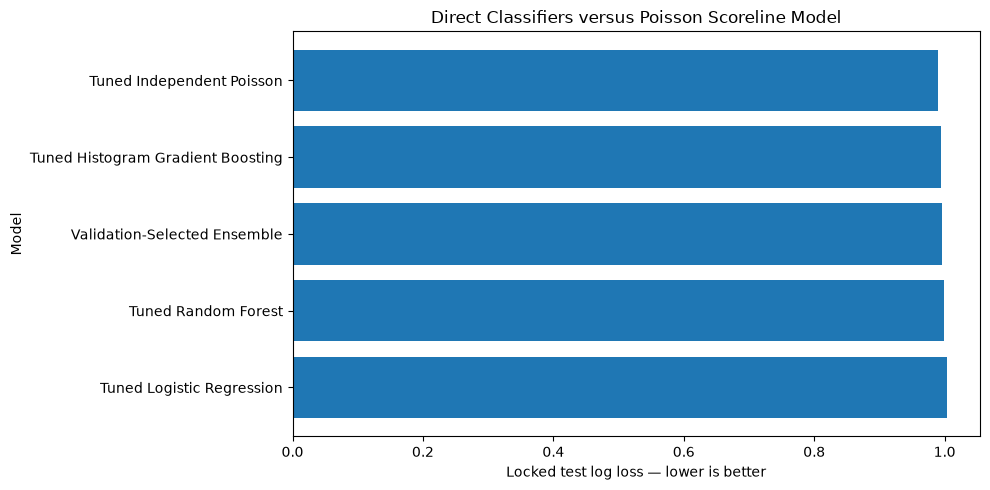

In [8]:
# ============================================================
# 9. Comparison with Direct H/D/A Models
# ============================================================

# Locked values produced in Notebooks 3 and 4 using the same split.
direct_model_reference = pd.DataFrame(
    [
        {
            "Model": "Tuned Logistic Regression",
            "ValidationLogLoss": 0.934551,
            "TestLogLoss": 1.004062,
        },
        {
            "Model": "Tuned Random Forest",
            "ValidationLogLoss": 0.936744,
            "TestLogLoss": 0.998788,
        },
        {
            "Model": "Tuned Histogram Gradient Boosting",
            "ValidationLogLoss": 0.937378,
            "TestLogLoss": 0.995154,
        },
        {
            "Model": "Validation-Selected Ensemble",
            "ValidationLogLoss": 0.931185,
            "TestLogLoss": 0.996526,
        },
    ]
)

poisson_reference_row = pd.DataFrame(
    [
        {
            "Model": "Tuned Independent Poisson",
            "ValidationLogLoss": validation_log_loss,
            "TestLogLoss": test_log_loss,
        }
    ]
)

model_family_comparison = pd.concat(
    [direct_model_reference, poisson_reference_row],
    ignore_index=True,
)

model_family_comparison["ValidationRank"] = (
    model_family_comparison["ValidationLogLoss"]
    .rank(method="min", ascending=True)
    .astype(int)
)

model_family_comparison["TestRank"] = (
    model_family_comparison["TestLogLoss"]
    .rank(method="min", ascending=True)
    .astype(int)
)

model_family_comparison = (
    model_family_comparison
    .sort_values(
        by="TestLogLoss",
        kind="mergesort",
    )
    .reset_index(drop=True)
)

poisson_test_rank = int(
    model_family_comparison.loc[
        model_family_comparison["Model"]
        == "Tuned Independent Poisson",
        "TestRank",
    ].iloc[0]
)

leading_test_model = model_family_comparison.iloc[0]

print("Model-family comparison completed successfully.")
print(
    "Leading locked-test model:",
    leading_test_model["Model"],
)
print(
    "Leading locked-test log loss:",
    round(float(leading_test_model["TestLogLoss"]), 6),
)
print(f"Poisson locked-test rank: {poisson_test_rank}")

display(model_family_comparison.round(6))

plt.figure(figsize=(10, 5))
plot_table = model_family_comparison.sort_values(
    "TestLogLoss",
    ascending=False,
)
plt.barh(
    plot_table["Model"],
    plot_table["TestLogLoss"],
)
plt.xlabel("Locked test log loss — lower is better")
plt.ylabel("Model")
plt.title("Direct Classifiers versus Poisson Scoreline Model")
plt.tight_layout()
plt.show()


### Results and interpretation

The tuned independent Poisson model achieved the strongest locked-test probability performance of every model evaluated in the project so far.

Its locked-test log loss was:

$$
\operatorname{LogLoss}_{\mathrm{Poisson,test}}
=
0.990298.
$$

The previous leading direct model, tuned Histogram Gradient Boosting, achieved 0.995154. The Poisson model therefore improved test log loss by:

$$
0.995154-0.990298
=
0.004856,
$$

or approximately 0.49% relative to Histogram Gradient Boosting.

The complete locked-test ranking was:

| Model | Test Log Loss |
|---|---:|
| Tuned Independent Poisson | 0.990298 |
| Tuned Histogram Gradient Boosting | 0.995154 |
| Validation-Selected Ensemble | 0.996526 |
| Tuned Random Forest | 0.998788 |
| Tuned Logistic Regression | 1.004062 |

This is an important result. The direct classifiers estimate H/D/A probabilities immediately, whereas the Poisson model first estimates the underlying home- and away-scoring rates and derives match-result probabilities from the resulting scoreline distribution. On this locked season, explicitly modelling the goal-generating process produced the most informative probability forecasts.

The difference between the leading models remains small, so the result should be tested across several walk-forward seasons before concluding that Poisson is universally superior.

## 10. Fixture-Level Expected Goals and Scoreline Analysis

This section converts the locked test forecasts into an interpretable fixture table.

For each match, it records:

- model-implied home expected goals;
- model-implied away expected goals;
- H/D/A probabilities;
- predicted outcome;
- most likely exact scoreline.

A scoreline heatmap is then created for the test fixture on which the model has the highest outcome confidence.


Fixture-level Poisson outputs created successfully.
Example fixture: Liverpool vs Southampton
Expected goals: {'Home': 4.551, 'Away': 0.42}


C:\Users\kiera\AppData\Local\Temp\ipykernel_6696\789486325.py:181: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].head(20).round(4)


,Season,Date,HomeTeam,AwayTeam,ActualHomeGoals,ActualAwayGoals,HomeExpectedGoals,AwayExpectedGoals,Probability_H,Probability_D,Probability_A,PredictedOutcome,MostLikelyScore
3420,2024-25,2024-08-16,Man United,Fulham,1,0,1.8116,1.1572,0.5269,0.2305,0.2426,H,1-1
3421,2024-25,2024-08-17,Arsenal,Wolves,2,0,2.9247,0.5817,0.8452,0.1073,0.0475,H,2-0
3422,2024-25,2024-08-17,Everton,Brighton,0,3,1.5166,1.2848,0.4270,0.2508,0.3222,H,1-1
3423,2024-25,2024-08-17,Ipswich,Liverpool,0,2,1.1268,1.9146,0.2210,0.2217,0.5573,A,1-1
3424,2024-25,2024-08-17,Newcastle,Southampton,1,0,2.1024,0.8104,0.6723,0.1946,0.1331,H,2-0
3425,2024-25,2024-08-17,Nott'm Forest,Bournemouth,1,1,1.1789,1.5715,0.2859,0.2498,0.4643,A,1-1
3426,2024-25,2024-08-17,West Ham,Aston Villa,1,2,1.1482,1.7682,0.2469,0.2341,0.5189,A,1-1
3427,2024-25,2024-08-18,Brentford,Crystal Palace,2,1,1.4315,1.3619,0.3893,0.2530,0.3577,H,1-1
3428,2024-25,2024-08-18,Chelsea,Man City,0,2,1.3181,1.8132,0.2794,0.2296,0.4910,A,1-1
3429,2024-25,2024-08-19,Leicester,Tottenham,1,1,1.3193,1.6913,0.2998,0.2380,0.4622,A,1-1


,Scoreline,HomeGoals,AwayGoals,Probability
0,4-0,4,0,0.15035
1,5-0,5,0,0.13684
2,3-0,3,0,0.13216
3,6-0,6,0,0.10378
4,2-0,2,0,0.08712
5,4-1,4,1,0.06317
6,5-1,5,1,0.05749
7,3-1,3,1,0.05552
8,6-1,6,1,0.04360
9,1-0,1,0,0.03829


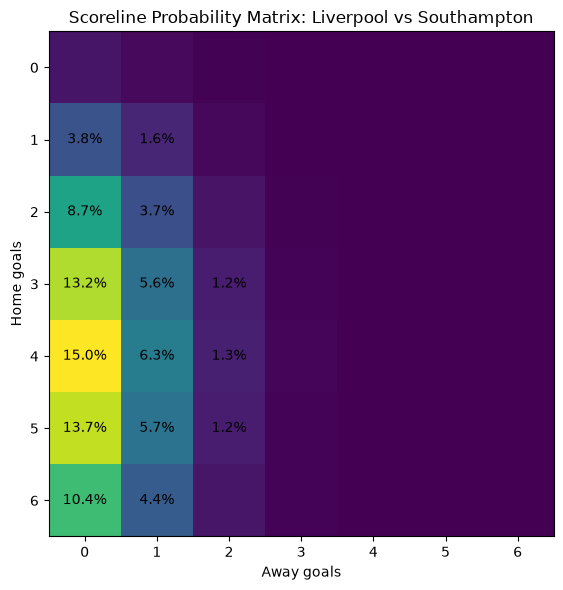

In [9]:
# ============================================================
# 10. Fixture-Level Expected Goals and Scoreline Analysis
# ============================================================


def most_likely_exact_score(
    home_expected_goals,
    away_expected_goals,
    max_exact_goals=8,
):
    """Return the most likely exact score within a practical range."""
    matrix = create_scoreline_probability_matrix(
        home_expected_goals,
        away_expected_goals,
        max_goals=max_exact_goals,
        fold_tail=False,
    )

    home_goals, away_goals = np.unravel_index(
        np.argmax(matrix),
        matrix.shape,
    )

    return (
        f"{home_goals}-{away_goals}",
        float(matrix[home_goals, away_goals]),
    )


def build_fixture_forecast_table(
    fixture_metadata,
    actual_outcomes,
    actual_home_goals,
    actual_away_goals,
    home_expected_goals,
    away_expected_goals,
    outcome_probabilities,
):
    """Create an auditable fixture-level forecast table."""
    output = fixture_metadata.copy()
    output["ActualHomeGoals"] = actual_home_goals
    output["ActualAwayGoals"] = actual_away_goals
    output["ActualOutcome"] = actual_outcomes
    output["HomeExpectedGoals"] = home_expected_goals
    output["AwayExpectedGoals"] = away_expected_goals

    for outcome in class_order:
        output[f"Probability_{outcome}"] = (
            outcome_probabilities[outcome]
        )

    output["PredictedOutcome"] = (
        outcome_probabilities.idxmax(axis=1)
    )

    likely_scores = [
        most_likely_exact_score(home_rate, away_rate)
        for home_rate, away_rate in zip(
            home_expected_goals,
            away_expected_goals,
        )
    ]

    output["MostLikelyScore"] = [
        score for score, probability in likely_scores
    ]

    output["MostLikelyScoreProbability"] = [
        probability for score, probability in likely_scores
    ]

    output["ProbabilityOfActualOutcome"] = [
        outcome_probabilities.loc[index, outcome]
        for index, outcome in actual_outcomes.items()
    ]

    return output


validation_poisson_output = build_fixture_forecast_table(
    metadata_validation,
    y_validation_outcome,
    y_validation_home_goals,
    y_validation_away_goals,
    best_validation_home_expected_goals,
    best_validation_away_expected_goals,
    best_validation_poisson_probabilities,
)

test_poisson_output = build_fixture_forecast_table(
    metadata_test,
    y_test_outcome,
    y_test_home_goals,
    y_test_away_goals,
    best_test_home_expected_goals,
    best_test_away_expected_goals,
    best_test_poisson_probabilities,
)

assert validation_poisson_output.index.equals(
    y_validation_outcome.index
)
assert test_poisson_output.index.equals(y_test_outcome.index)

example_fixture_index = (
    best_test_poisson_probabilities
    .max(axis=1)
    .idxmax()
)

example_fixture = test_poisson_output.loc[
    example_fixture_index
]

example_home_expected_goals = float(
    example_fixture["HomeExpectedGoals"]
)

example_away_expected_goals = float(
    example_fixture["AwayExpectedGoals"]
)

example_scoreline_matrix = create_scoreline_probability_matrix(
    example_home_expected_goals,
    example_away_expected_goals,
    max_goals=6,
    fold_tail=False,
)

scoreline_records = []

for home_goals in range(example_scoreline_matrix.shape[0]):
    for away_goals in range(example_scoreline_matrix.shape[1]):
        scoreline_records.append(
            {
                "Scoreline": f"{home_goals}-{away_goals}",
                "HomeGoals": home_goals,
                "AwayGoals": away_goals,
                "Probability": example_scoreline_matrix[
                    home_goals,
                    away_goals,
                ],
            }
        )

top_example_scorelines = (
    pd.DataFrame(scoreline_records)
    .sort_values("Probability", ascending=False)
    .head(12)
    .reset_index(drop=True)
)

print("Fixture-level Poisson outputs created successfully.")
print(
    "Example fixture:",
    f"{example_fixture[home_team_column]} vs "
    f"{example_fixture[away_team_column]}",
)
print(
    "Expected goals:",
    {
        "Home": round(example_home_expected_goals, 3),
        "Away": round(example_away_expected_goals, 3),
    },
)

display(
    test_poisson_output[
        identifier_columns
        + [
            "ActualHomeGoals",
            "ActualAwayGoals",
            "HomeExpectedGoals",
            "AwayExpectedGoals",
            "Probability_H",
            "Probability_D",
            "Probability_A",
            "PredictedOutcome",
            "MostLikelyScore",
        ]
    ].head(20).round(4)
)

display(top_example_scorelines.round(5))

plt.figure(figsize=(8, 6))
plt.imshow(example_scoreline_matrix)
plt.xticks(
    range(example_scoreline_matrix.shape[1]),
    range(example_scoreline_matrix.shape[1]),
)
plt.yticks(
    range(example_scoreline_matrix.shape[0]),
    range(example_scoreline_matrix.shape[0]),
)
plt.xlabel("Away goals")
plt.ylabel("Home goals")
plt.title(
    "Scoreline Probability Matrix: "
    f"{example_fixture[home_team_column]} vs "
    f"{example_fixture[away_team_column]}"
)

for home_goals in range(example_scoreline_matrix.shape[0]):
    for away_goals in range(example_scoreline_matrix.shape[1]):
        probability = example_scoreline_matrix[
            home_goals,
            away_goals,
        ]

        if probability >= 0.01:
            plt.text(
                away_goals,
                home_goals,
                f"{100 * probability:.1f}%",
                ha="center",
                va="center",
            )

plt.tight_layout()
plt.show()


### Results and interpretation

The example fixture was Liverpool versus Southampton. The model produced pre-match expected goals of:

$$
\widehat{\lambda}_H=4.551,
\qquad
\widehat{\lambda}_A=0.420.
$$

The most likely exact score was 4–0 with probability 15.04%, followed by 5–0 at 13.68% and 3–0 at 13.22%.

The heatmap makes the complete forecast structure visible. Draw probability lies on the diagonal, home-win probability below the diagonal and away-win probability above it.

This illustrates the main informational advantage of the scoreline framework. A direct classifier returns only H/D/A probabilities, whereas the Poisson model simultaneously provides model-implied expected goals, exact-score probabilities and match-result probabilities. These outputs can later support match simulation, score-market analysis and richer prediction reporting.

The expected goals should be described as **model-implied pre-match expected goals**. They are not conventional shot-based xG because they are inferred from historical pre-match features rather than event-level shot quality.

## 11. Coefficient and Forecast Diagnostics

Because the predictors were standardised before fitting, coefficient magnitudes are more comparable than they would be on their original scales.

A positive home-model coefficient is associated with a higher expected home-goal rate, holding the other model variables fixed. A negative coefficient is associated with a lower rate.

The same interpretation applies separately to the away-goal model.

These are model associations, not causal effects. Correlated predictors can also divide importance between themselves.


Poisson coefficient diagnostics completed successfully.


,Split,MinimumHomeExpectedGoals,MaximumHomeExpectedGoals,MinimumAwayExpectedGoals,MaximumAwayExpectedGoals
0,Train,0.0068,4.1521,0.3619,3.4106
1,Validation,0.0014,4.1370,0.3182,3.4317
2,Test,0.5680,4.5506,0.4201,3.1498


,Feature,Coefficient
0,HomeRollingGoalDifference5,-10.170625
1,PointsFormDifference5,-8.158073
2,GoalsAgainstFormDifference5,-6.388386
3,HomeRollingPoints5,5.726441
4,AwayRollingPoints5,-5.717581
5,HomeRollingGoalsFor5,5.321662
6,VenueGoalDifferenceFormDifference5,5.048500
7,AwayRollingGoalsAgainst5,-4.548586
8,AwayVenueRollingGoalDifference5,3.448598
9,GoalDifferenceFormDifference5,3.447859


,Feature,Coefficient
0,VenuePointsFormDifference5,-0.272231
1,HomeVenueRollingPoints5,0.259551
2,HomeRollingGoalDifference5,0.225677
3,HomeRollingGoalsAgainst5,0.216651
4,VenueGoalsAgainstFormDifference5,0.197169
5,AwayVenueRollingGoalsAgainst5,0.154910
6,AwayRollingPoints5,-0.141615
7,VenueGoalsForFormDifference5,0.137295
8,AwayVenueRollingPoints5,-0.129193
9,EloDifference,-0.119217


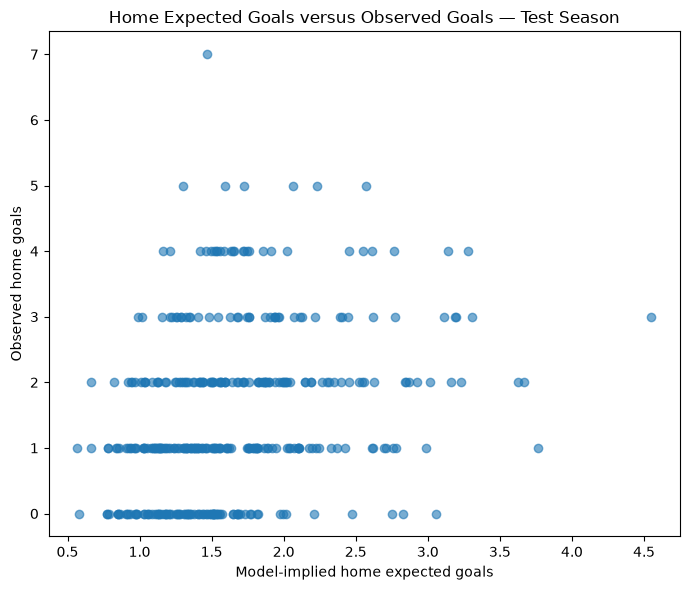

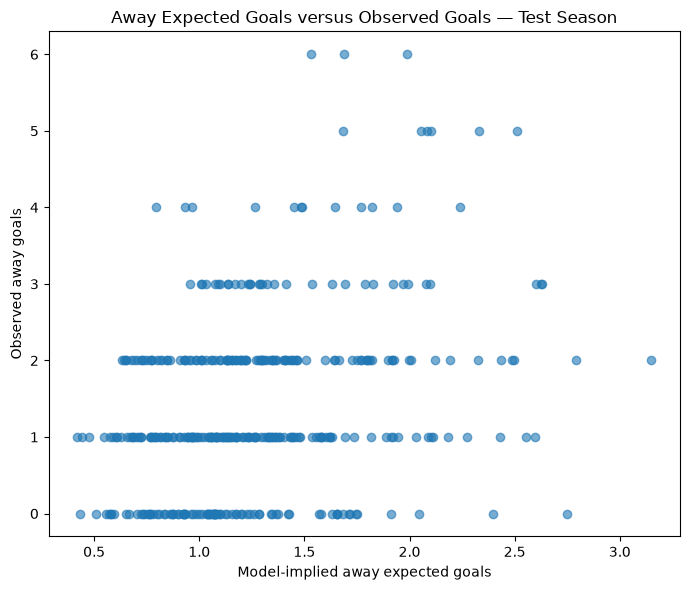

In [10]:
# ============================================================
# 11. Coefficient and Forecast Diagnostics
# ============================================================

home_coefficient_table = (
    pd.Series(
        best_home_poisson_model.coef_,
        index=feature_columns,
        name="Coefficient",
    )
    .rename_axis("Feature")
    .reset_index()
)

away_coefficient_table = (
    pd.Series(
        best_away_poisson_model.coef_,
        index=feature_columns,
        name="Coefficient",
    )
    .rename_axis("Feature")
    .reset_index()
)

home_coefficient_table["AbsoluteCoefficient"] = (
    home_coefficient_table["Coefficient"].abs()
)

away_coefficient_table["AbsoluteCoefficient"] = (
    away_coefficient_table["Coefficient"].abs()
)

home_largest_coefficients = (
    home_coefficient_table
    .sort_values(
        "AbsoluteCoefficient",
        ascending=False,
    )
    .head(20)
    .reset_index(drop=True)
)

away_largest_coefficients = (
    away_coefficient_table
    .sort_values(
        "AbsoluteCoefficient",
        ascending=False,
    )
    .head(20)
    .reset_index(drop=True)
)

expected_goal_range_summary = pd.DataFrame(
    {
        "Split": ["Train", "Validation", "Test"],
        "MinimumHomeExpectedGoals": [
            best_train_home_expected_goals.min(),
            best_validation_home_expected_goals.min(),
            best_test_home_expected_goals.min(),
        ],
        "MaximumHomeExpectedGoals": [
            best_train_home_expected_goals.max(),
            best_validation_home_expected_goals.max(),
            best_test_home_expected_goals.max(),
        ],
        "MinimumAwayExpectedGoals": [
            best_train_away_expected_goals.min(),
            best_validation_away_expected_goals.min(),
            best_test_away_expected_goals.min(),
        ],
        "MaximumAwayExpectedGoals": [
            best_train_away_expected_goals.max(),
            best_validation_away_expected_goals.max(),
            best_test_away_expected_goals.max(),
        ],
    }
)

assert np.isfinite(
    home_coefficient_table["Coefficient"]
).all()
assert np.isfinite(
    away_coefficient_table["Coefficient"]
).all()
assert (best_test_home_expected_goals > 0).all()
assert (best_test_away_expected_goals > 0).all()

print("Poisson coefficient diagnostics completed successfully.")

display(expected_goal_range_summary.round(4))

display(
    home_largest_coefficients[
        ["Feature", "Coefficient"]
    ].round(6)
)

display(
    away_largest_coefficients[
        ["Feature", "Coefficient"]
    ].round(6)
)

plt.figure(figsize=(7, 6))
plt.scatter(
    best_test_home_expected_goals,
    y_test_home_goals,
    alpha=0.6,
)
plt.xlabel("Model-implied home expected goals")
plt.ylabel("Observed home goals")
plt.title("Home Expected Goals versus Observed Goals — Test Season")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(
    best_test_away_expected_goals,
    y_test_away_goals,
    alpha=0.6,
)
plt.xlabel("Model-implied away expected goals")
plt.ylabel("Observed away goals")
plt.title("Away Expected Goals versus Observed Goals — Test Season")
plt.tight_layout()
plt.show()


### Results and interpretation

The expected-goal forecasts remained within plausible test-period ranges. Home expected goals ranged from 0.5680 to 4.5506, while away expected goals ranged from 0.4201 to 3.1498.

Recent form variables feature prominently in both models. The home-goal model relies heavily on rolling goal difference, points form, goals-against form and recent goals scored. The away-goal model also assigns meaningful weight to venue-specific points, goals-against measures, Elo difference and league-table information.

Because several engineered predictors are strongly correlated, individual coefficient signs and magnitudes should not be interpreted in isolation. In particular, the unregularised selected home model produces some large coefficients that may reflect shared information being divided across related variables rather than stable standalone effects.

The coefficient tables therefore describe model dependence, not causality. The scatter plots are intended to reveal systematic compression or extreme forecasts rather than a narrow relationship, because individual football scorelines remain highly noisy even when their expected values are estimated well.

## 12. Export Reproducible Poisson Outputs

The validation and locked-test forecasts are saved for later notebooks.

Saving fixture-level out-of-sample probabilities avoids repeatedly rebuilding the scoreline model when performing:

- walk-forward evaluation;
- probability calibration;
- model blending;
- bookmaker comparison;
- future prediction reporting.

Only predictions, metrics and configuration are exported. No test-based tuning is performed during export.


In [11]:
# ============================================================
# 12. Export Reproducible Poisson Outputs
# ============================================================

output_table_directory = (
    project_root
    / "outputs"
    / "tables"
)

output_table_directory.mkdir(
    parents=True,
    exist_ok=True,
)

validation_prediction_path = (
    output_table_directory
    / "poisson_validation_predictions.csv"
)

test_prediction_path = (
    output_table_directory
    / "poisson_test_predictions.csv"
)

search_result_path = (
    output_table_directory
    / "poisson_hyperparameter_search.csv"
)

model_comparison_path = (
    output_table_directory
    / "poisson_model_family_comparison.csv"
)

outcome_metric_path = (
    output_table_directory
    / "poisson_outcome_metrics.csv"
)

goal_metric_path = (
    output_table_directory
    / "poisson_goal_metrics.csv"
)

configuration_path = (
    output_table_directory
    / "poisson_configuration.json"
)

validation_poisson_output.to_csv(
    validation_prediction_path,
    index=False,
)

test_poisson_output.to_csv(
    test_prediction_path,
    index=False,
)

poisson_search_results.to_csv(
    search_result_path,
    index=False,
)

model_family_comparison.to_csv(
    model_comparison_path,
    index=False,
)

poisson_outcome_results.to_csv(
    outcome_metric_path,
    index=False,
)

poisson_goal_results.to_csv(
    goal_metric_path,
    index=False,
)

poisson_configuration = {
    "training_seasons": training_seasons,
    "validation_season": validation_season,
    "test_season": test_season,
    "home_alpha": best_home_alpha,
    "away_alpha": best_away_alpha,
    "maximum_modelled_goals": MAX_MODELLED_GOALS,
    "feature_count": len(feature_columns),
    "validation_log_loss": validation_log_loss,
    "test_log_loss": test_log_loss,
}

with configuration_path.open("w", encoding="utf-8") as file:
    json.dump(
        poisson_configuration,
        file,
        indent=2,
    )

export_summary = pd.DataFrame(
    {
        "Output": [
            "Validation predictions",
            "Test predictions",
            "Hyperparameter search",
            "Model-family comparison",
            "Outcome metrics",
            "Goal metrics",
            "Configuration",
        ],
        "Path": [
            validation_prediction_path.relative_to(project_root),
            test_prediction_path.relative_to(project_root),
            search_result_path.relative_to(project_root),
            model_comparison_path.relative_to(project_root),
            outcome_metric_path.relative_to(project_root),
            goal_metric_path.relative_to(project_root),
            configuration_path.relative_to(project_root),
        ],
    }
)

for output_path in [
    validation_prediction_path,
    test_prediction_path,
    search_result_path,
    model_comparison_path,
    outcome_metric_path,
    goal_metric_path,
    configuration_path,
]:
    assert output_path.exists(), (
        f"Expected export was not created: {output_path}"
    )

print("Poisson outputs exported successfully.")
display(export_summary)


Poisson outputs exported successfully.


,Output,Path
0,Validation predictions,outputs\tables\poisson_validation_predictions.csv
1,Test predictions,outputs\tables\poisson_test_predictions.csv
2,Hyperparameter search,outputs\tables\poisson_hyperparameter_search.csv
3,Model-family comparison,outputs\tables\poisson_model_family_comparison...
4,Outcome metrics,outputs\tables\poisson_outcome_metrics.csv
5,Goal metrics,outputs\tables\poisson_goal_metrics.csv
6,Configuration,outputs\tables\poisson_configuration.json


## 13. Automatic Research Summary

The final cell converts the numerical results into a concise, reproducible conclusion. It does not alter the model or select a new specification.


In [12]:
# ============================================================
# 13. Automatic Research Summary
# ============================================================

constant_validation_log_loss = float(
    constant_poisson_outcome_results.loc[
        constant_poisson_outcome_results["Split"]
        == "Validation",
        "LogLoss",
    ].iloc[0]
)

constant_test_log_loss = float(
    constant_poisson_outcome_results.loc[
        constant_poisson_outcome_results["Split"]
        == "Test",
        "LogLoss",
    ].iloc[0]
)

validation_improvement_vs_constant = (
    100
    * (
        constant_validation_log_loss
        - validation_log_loss
    )
    / constant_validation_log_loss
)

test_improvement_vs_constant = (
    100
    * (
        constant_test_log_loss
        - test_log_loss
    )
    / constant_test_log_loss
)

best_direct_test_log_loss = float(
    direct_model_reference["TestLogLoss"].min()
)

best_direct_test_model = (
    direct_model_reference.loc[
        direct_model_reference["TestLogLoss"].idxmin(),
        "Model",
    ]
)

if test_log_loss < best_direct_test_log_loss:
    direct_comparison_statement = (
        "The tuned Poisson model achieved a lower locked-test "
        "log loss than every previously evaluated direct model."
    )

elif np.isclose(
    test_log_loss,
    best_direct_test_log_loss,
    atol=0.002,
):
    direct_comparison_statement = (
        "The tuned Poisson model performed within 0.002 log-loss "
        "points of the leading direct model, making it strongly "
        "competitive despite using a different score-based structure."
    )

else:
    direct_comparison_statement = (
        "The tuned Poisson model did not beat the leading direct "
        "model on the locked test season, but it provides expected-"
        "goal and scoreline information that the direct classifiers "
        "cannot produce."
    )

print("=" * 72)
print("POISSON SCORELINE MODELLING — FINAL SUMMARY")
print("=" * 72)
print()
print(f"Selected home alpha: {best_home_alpha}")
print(f"Selected away alpha: {best_away_alpha}")
print(f"Validation log loss: {validation_log_loss:.6f}")
print(f"Locked test log loss: {test_log_loss:.6f}")
print()
print(
    "Validation improvement versus constant-rate Poisson: "
    f"{validation_improvement_vs_constant:.2f}%"
)
print(
    "Test improvement versus constant-rate Poisson: "
    f"{test_improvement_vs_constant:.2f}%"
)
print()
print(
    "Leading previous direct model on test: "
    f"{best_direct_test_model} "
    f"({best_direct_test_log_loss:.6f})"
)
print(direct_comparison_statement)
print()
print(
    "Methodological conclusion: the test season remained locked, "
    "and no hyperparameter was changed after its results were seen."
)


POISSON SCORELINE MODELLING — FINAL SUMMARY

Selected home alpha: 0.0
Selected away alpha: 0.001
Validation log loss: 0.920675
Locked test log loss: 0.990298

Validation improvement versus constant-rate Poisson: 12.87%
Test improvement versus constant-rate Poisson: 8.41%

Leading previous direct model on test: Tuned Histogram Gradient Boosting (0.995154)
The tuned Poisson model achieved a lower locked-test log loss than every previously evaluated direct model.

Methodological conclusion: the test season remained locked, and no hyperparameter was changed after its results were seen.


## 14. Conclusions, Limitations and Next Stage

This notebook developed a complete independent Poisson scoreline framework. Full-time goals were isolated as targets, leakage-safe pre-match predictors were retained, home and away scoring rates were modelled separately, and the predicted rates were transformed into scoreline and H/D/A probability distributions.

The selected specification used:

$$
\alpha_H=0,
\qquad
\alpha_A=0.001.
$$

It achieved a validation log loss of 0.920675 and a locked-test log loss of 0.990298. Relative to the constant-rate Poisson benchmark, this reduced log loss by approximately 12.87% on validation and 8.41% on test.

Most importantly, the Poisson model produced the lowest locked-test log loss of all model families evaluated so far. It narrowly outperformed tuned Histogram Gradient Boosting at 0.995154, the validation-selected ensemble at 0.996526, Random Forest at 0.998788 and logistic regression at 1.004062.

The result suggests that modelling the underlying goal-scoring process can provide predictive information beyond direct H/D/A classification. It also produces richer outputs, including model-implied expected goals and exact-score probabilities.

### Limitations

The framework assumes conditional independence between home and away goals. In real matches, the two scoring processes can interact through game state, red cards and tactical responses.

The ordinary Poisson distribution also constrains the conditional mean and variance to be equal. The observed data show mild overdispersion in several samples, so negative-binomial modelling may be worth testing.

Low-scoring outcomes such as 0–0 and 1–1 can exhibit dependence not captured by the independent model. A Dixon–Coles adjustment is a natural extension.

The selected home model used no regularisation and reached the current optimisation iteration limit during the search. Before the notebook is treated as final, the model should be rerun with a larger iteration allowance to verify numerical convergence and coefficient stability.

The expected goals are model-implied pre-match rates, not event-level shot-quality xG.

Finally, the current ranking is based on one validation season and one locked-test season. The small differences between the leading models may not persist through every period.

### Next stage

The next notebook should be:

`06_walk_forward_backtesting.ipynb`

It will repeatedly train on earlier seasons and predict the following season. This will determine whether the Poisson model's lead is stable or driven by the current split, and will create a larger archive of genuinely out-of-sample probabilities for calibration, model blending and bookmaker comparison.

### Interview explanation

> I modelled home and away goals separately with Poisson regressions, transformed the predicted rates into full scoreline matrices and aggregated those matrices into match-result probabilities. I selected the two regularisation strengths chronologically using validation log loss and kept the final season locked. The Poisson model achieved the strongest locked-test log loss in the project, while also producing interpretable expected-goal and exact-score forecasts.